# Chapter 6 &mdash; Qualitative Classification of CA

Across all the CA we've met, long-term behavior sorts into just
**four qualitative classes** (Stephen Wolfram): homogeneous,
periodic, chaotic, and complex. The simplest arena to see them is
the family of **elementary CA** &mdash; $k=2$, nearest neighbors, so
exactly $2^8 = 256$ possible rules, each with a number 0&ndash;255.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn import ca1d

## Wolfram's rule numbering

List the 8 neighborhoods `111, 110, ..., 001, 000` and write the
new center value under each; read those 8 bits as a number. For
example **Rule 90** turns out to be the additive kernel
$[1\,0\,1] \bmod 2$ &mdash; our Sierpi\u0144ski gasket &mdash; in
disguise. Let's confirm that.

In [3]:
init = ca1d.single_seed(129)
a = ca1d.run_elementary(init, rule=90, generations=20)
b = ca1d.run_additive(init, [1, 0, 1], k=2, generations=20)
print("Rule 90 == kernel [1 0 1] mod 2:", np.array_equal(a, b))

Rule 90 == kernel [1 0 1] mod 2: True


## The four classes

One representative rule from each class, evolved from the **same**
random initial row:

- **Class 1 (homogeneous):** Rule 160 &mdash; dies to a blank state.
- **Class 2 (periodic):** Rule 108 &mdash; freezes into stable /
  blinking stripes.
- **Class 3 (chaotic):** Rule 30 &mdash; boils into noise (it's even
  used as a pseudo-random generator).
- **Class 4 (complex):** Rule 110 &mdash; localized particles that
  move and interact; *Turing complete*.

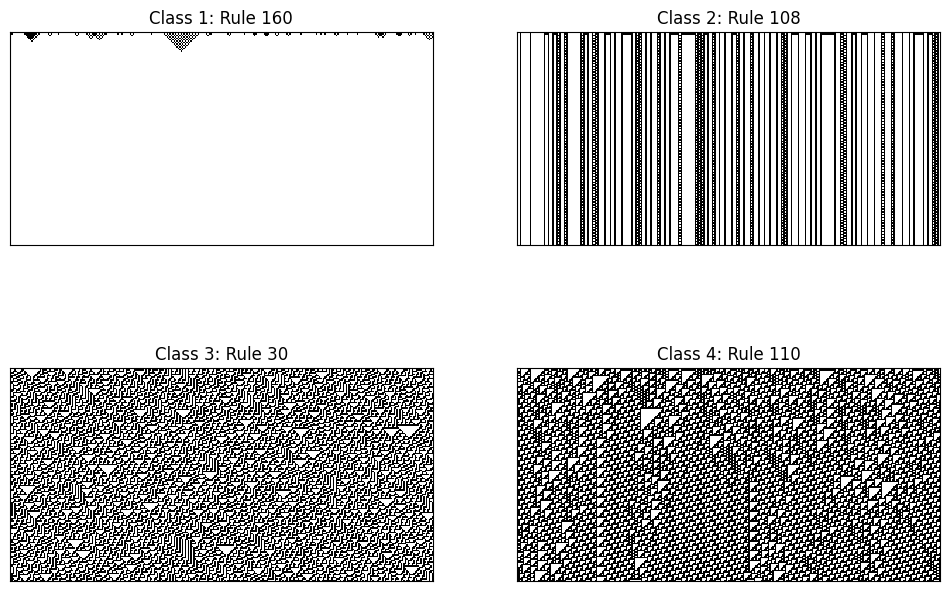

In [4]:
rng = np.random.default_rng(0)
init = rng.integers(0, 2, 300)
classes = [(160, "Class 1: Rule 160"), (108, "Class 2: Rule 108"),
           (30,  "Class 3: Rule 30"),  (110, "Class 4: Rule 110")]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (rule, label) in zip(axes.flat, classes):
    h = ca1d.run_elementary(init, rule, 150)
    ax.imshow(h, cmap="binary", interpolation="nearest", aspect="equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(label)
plt.show()

## Rule 110's particles up close

Class 4 is the interesting one: neither frozen nor random, but
structured. From a random start, Rule 110 threads persistent
moving structures &mdash; the raw material Matthew Cook used to
prove it computationally **universal**.

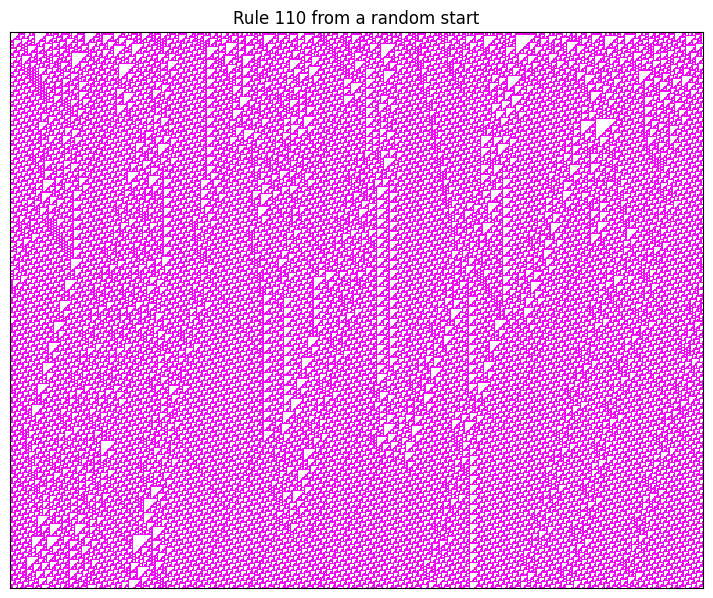

In [5]:
h = ca1d.run_elementary(rng.integers(0, 2, 500), rule=110, generations=400)
ca1d.plot_spacetime(h, k=2, title="Rule 110 from a random start")
plt.show()

## Rule 30 as a random generator

From a *single* seed, Rule 30's center column is so disordered it
passes many statistical randomness tests. Let's look at its
triangular growth.

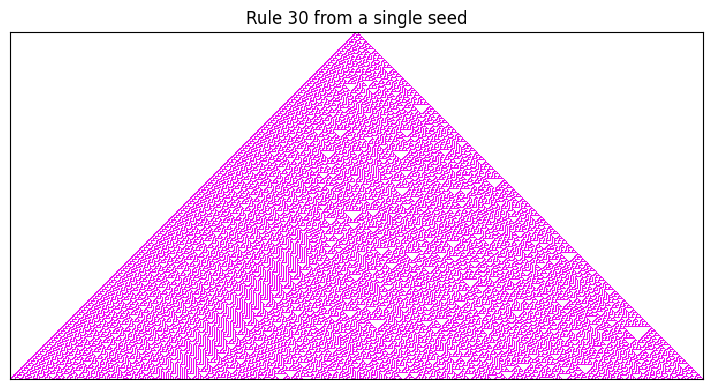

center-column bits, first 40 generations:
1101110011000101100100111010111001110101


In [6]:
h = ca1d.run_elementary(ca1d.single_seed(601), rule=30, generations=300)
ca1d.plot_spacetime(h, k=2, title="Rule 30 from a single seed")
plt.show()
center = h[:, h.shape[1] // 2]
print("center-column bits, first 40 generations:")
print("".join(map(str, center[:40])))

## Your turn

1. Browse the 256 rules. Some famous ones: 54 and 137 (Class 4
   candidates), 150 (additive, three-neighbor XOR), 184 (traffic
   flow), 60 (another Sierpi\u0144ski relative).
   ```python
   for rule in (54, 150, 184, 60):
       h = ca1d.run_elementary(ca1d.single_seed(301), rule, 150)
       ca1d.plot_spacetime(h, 2, title=f"Rule {rule}"); plt.show()
   ```
2. Which class does each land in? Is the classification always
   obvious &mdash; or genuinely ambiguous for some rules?
3. **Computational irreducibility:** for a Class 4 rule there is in
   general no shortcut &mdash; you must run it to know its future.
   Contrast with the additive rules of Chapter 3, whose polynomial
   form *is* a shortcut.